In [6]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV 
from sklearn.ensemble import GradientBoostingClassifier 
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

from scipy.stats import randint, uniform, skew, kurtosis

import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
#from xgboost import XGBClassifier

import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone

import operator

c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# ссылка на датасет - https://www.kaggle.com/datasets/programmer3/cross-sport-athlete-performance-dataset?select=running_data.csv
file_path = r'C:\Users\Anast.Andreeva1\Desktop\ML\archive\running_data.csv' 
df = pd.read_csv(file_path)

In [8]:
#настройка, котопая позволяет выводить все столбцы
pd.set_option('display.max_columns', None)
df.head()

,athlete_id,age,gender,sport,vo2_max,hrv,lactate_threshold,resting_heart_rate,max_heart_rate,stride_length,cadence,force_application,power_output,endurance_score,efficiency_score,adaptability_score,skiing_potential
0,RUN_1,23.0,Female,Running,62.21,116.50,75.97,45,179,1.08,89.0,466.50,NaN,91.94,75.17,91.67,0.54
1,RUN_2,20.0,Male,Running,50.98,98.90,78.68,41,198,0.80,65.0,528.12,NaN,65.22,64.80,80.85,0.13
2,RUN_3,22.0,Female,Running,68.55,56.96,72.11,49,179,0.92,97.0,304.43,NaN,50.73,61.85,93.61,0.93
3,RUN_4,26.0,Female,Running,57.89,56.20,83.94,56,192,0.89,60.0,520.07,NaN,77.56,94.52,70.17,0.15
4,RUN_5,22.0,Male,NaN,56.31,101.21,80.60,58,176,1.47,66.0,340.50,NaN,74.46,52.44,52.87,0.03


In [9]:
# смотрю на типы данных датасета (10 - float64, 4 - int64, 3 - object)
df.dtypes.value_counts()

float64    12
object      3
int64       2
Name: count, dtype: int64

In [10]:
df.dtypes

athlete_id             object
age                   float64
gender                 object
sport                  object
vo2_max               float64
hrv                   float64
lactate_threshold     float64
resting_heart_rate      int64
max_heart_rate          int64
stride_length         float64
cadence               float64
force_application     float64
power_output          float64
endurance_score       float64
efficiency_score      float64
adaptability_score    float64
skiing_potential      float64
dtype: object

In [11]:
# проверяю количество null
pd.DataFrame(df.isnull().sum(),
            columns = ['missing_count']) \
.assign(missing_pct = lambda x: x['missing_count']/df.shape[0]*100).astype(float).round(1)

,missing_count,missing_pct
athlete_id,0.0,0.0
age,5.0,0.4
gender,0.0,0.0
sport,17.0,1.5
vo2_max,0.0,0.0
hrv,0.0,0.0
lactate_threshold,0.0,0.0
resting_heart_rate,0.0,0.0
max_heart_rate,0.0,0.0
stride_length,0.0,0.0


In [12]:
# суммарная информация по датасету
# видим, что power_output все строки пустые. Имеет смысл этот признак исключить
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1158 entries, 0 to 1157
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   athlete_id          1158 non-null   object 
 1   age                 1153 non-null   float64
 2   gender              1158 non-null   object 
 3   sport               1141 non-null   object 
 4   vo2_max             1158 non-null   float64
 5   hrv                 1158 non-null   float64
 6   lactate_threshold   1158 non-null   float64
 7   resting_heart_rate  1158 non-null   int64  
 8   max_heart_rate      1158 non-null   int64  
 9   stride_length       1158 non-null   float64
 10  cadence             1152 non-null   float64
 11  force_application   1158 non-null   float64
 12  power_output        0 non-null      float64
 13  endurance_score     1158 non-null   float64
 14  efficiency_score    1158 non-null   float64
 15  adaptability_score  1136 non-null   float64
 16  skiing

In [13]:
# удаляю признак power_output, т.к. в датасете он по всем строкам пустой
df = df.drop('power_output', axis=1)

# Рапределения числовых признаков

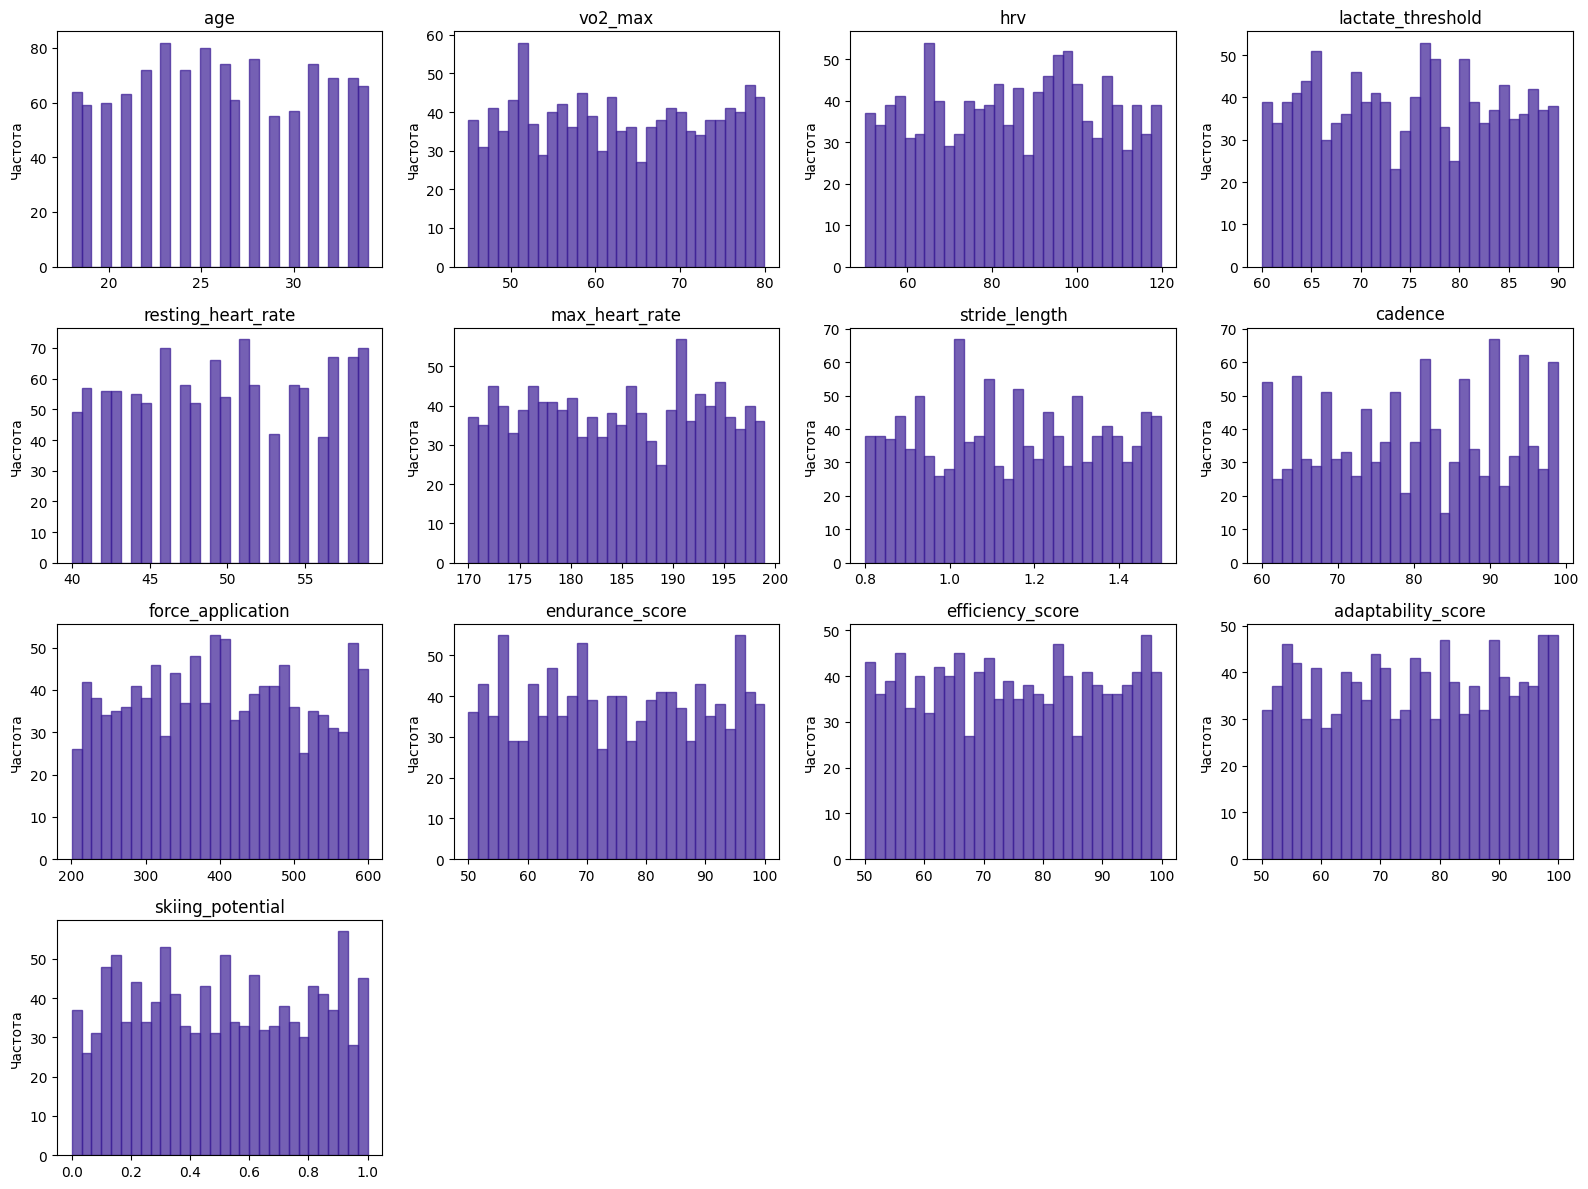

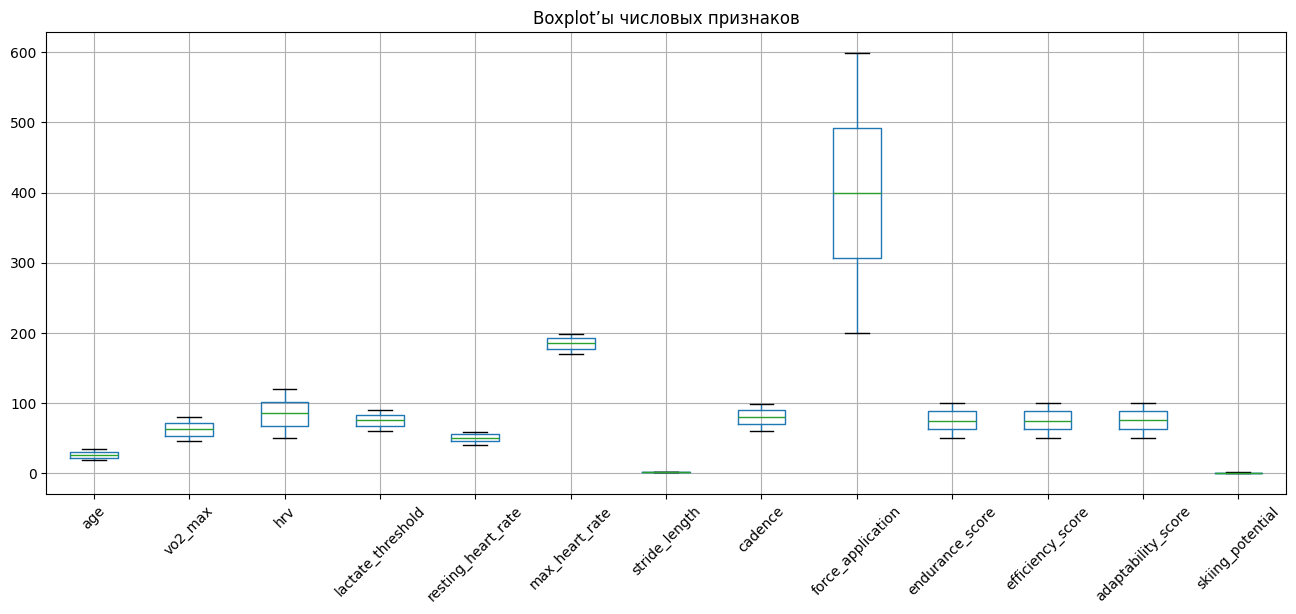

In [14]:
# Выбираю числовые признаки
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Гистограммы
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col].dropna(), bins=30, alpha=0.7, edgecolor="#3A1C95", color="#3A1C95")
    axes[i].set_title(col)
    axes[i].set_ylabel('Частота')

# Убираю пустые подграфики, если признаков меньше 16
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Boxplot’ы
plt.figure(figsize=(16, 6))
df[numeric_features].boxplot()
plt.title('Boxplot’ы числовых признаков')
plt.xticks(rotation=45)
plt.show()

# Анализ распределения признаков

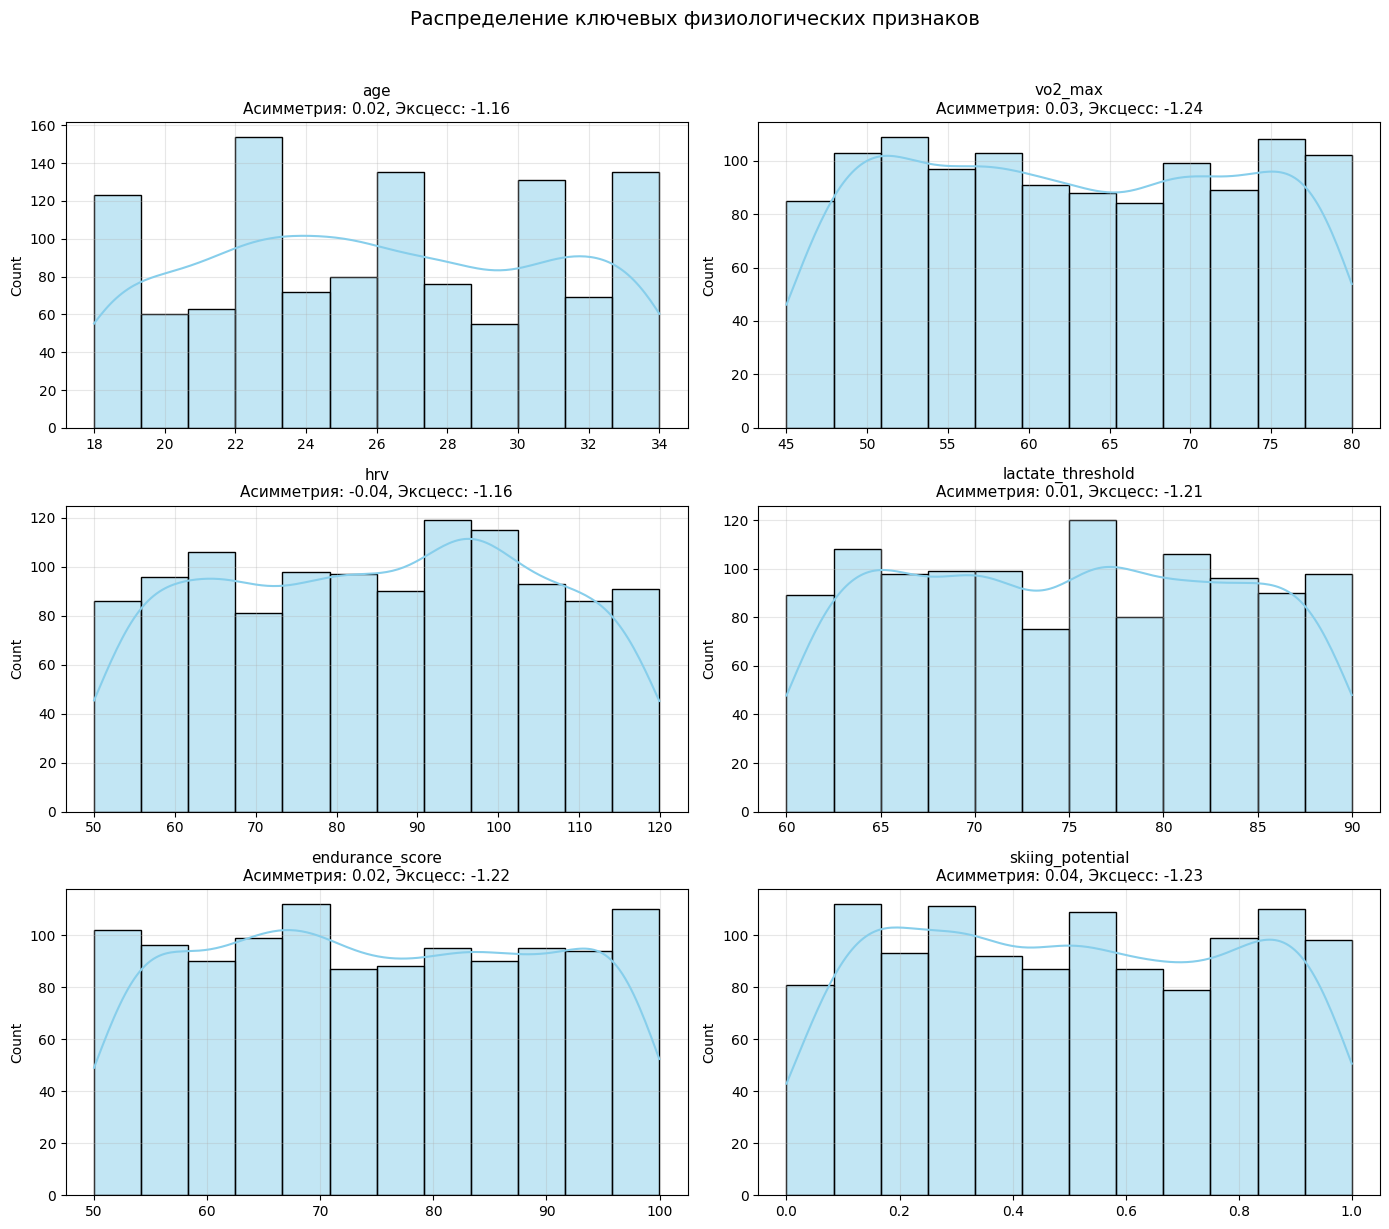


Анализ формы распределений:
Признак              | Асимметрия |  Эксцесс | Интерпретация
----------------------------------------------------------------------
age                  |      +0.02 |    -1.16 | Умеренная асимметрия (приемлемо)
vo2_max              |      +0.03 |    -1.24 | Умеренная асимметрия (приемлемо)
hrv                  |      -0.04 |    -1.16 | Умеренная асимметрия (приемлемо)
lactate_threshold    |      +0.01 |    -1.21 | Умеренная асимметрия (приемлемо)
resting_heart_rate   |      +0.00 |    -1.19 | Умеренная асимметрия (приемлемо)
max_heart_rate       |      -0.01 |    -1.24 | Умеренная асимметрия (приемлемо)
stride_length        |      +0.03 |    -1.18 | Умеренная асимметрия (приемлемо)
cadence              |      -0.04 |    -1.21 | Умеренная асимметрия (приемлемо)
force_application    |      +0.04 |    -1.11 | Умеренная асимметрия (приемлемо)
endurance_score      |      +0.02 |    -1.22 | Умеренная асимметрия (приемлемо)
efficiency_score     |      +0.01 |    

In [15]:
# Создаю комбинированную визуализацию для ключевых метрик
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel()

key_features = ['age', 'vo2_max', 'hrv', 'lactate_threshold', 'endurance_score', 'skiing_potential']

for idx, col in enumerate(key_features):
    data = df[col].dropna()
    
    # Гистограмма с KDE
    sns.histplot(data, kde=True, ax=axes[idx], color='skyblue', edgecolor='black')
    
    # Добавляю статистики на график
    s = skew(data)
    k = kurtosis(data, fisher=True)  # fisher=True: 0 для нормального
    
    axes[idx].set_title(f'{col}\nАсимметрия: {s:.2f}, Эксцесс: {k:.2f}', fontsize=11)
    axes[idx].set_xlabel('')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Распределение ключевых физиологических признаков', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Таблица формы распределения
print("\nАнализ формы распределений:")
print(f"{'Признак':<20} | {'Асимметрия':>10} | {'Эксцесс':>8} | {'Интерпретация'}")
print("-" * 70)

for col in numeric_features:
    data = df[col].dropna()
    s = skew(data)
    k = kurtosis(data, fisher=True)
    
    # Правила для ML:
    if abs(s) < 0.5 and abs(k) < 1:
        interp = "Близко к нормальному"
    elif abs(s) < 1 and k < 3:
        interp = "Умеренная асимметрия (приемлемо)"
    else:
        interp = "Сильное отклонение (лог-трансформация?)"
    
    print(f"{col:<20} | {s:>+10.2f} | {k:>+8.2f} | {interp}")

In [16]:
def check_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("\nАнализ выбросов (IQR):")
for col in numeric_features:
    n_outliers, lb, ub = check_outliers(df, col)
    print(f"{col:25} : {n_outliers:4} выбросов ({n_outliers/len(df)*100:.1f}%)")


Анализ выбросов (IQR):
age                       :    0 выбросов (0.0%)
vo2_max                   :    0 выбросов (0.0%)
hrv                       :    0 выбросов (0.0%)
lactate_threshold         :    0 выбросов (0.0%)
resting_heart_rate        :    0 выбросов (0.0%)
max_heart_rate            :    0 выбросов (0.0%)
stride_length             :    0 выбросов (0.0%)
cadence                   :    0 выбросов (0.0%)
force_application         :    0 выбросов (0.0%)
endurance_score           :    0 выбросов (0.0%)
efficiency_score          :    0 выбросов (0.0%)
adaptability_score        :    0 выбросов (0.0%)
skiing_potential          :    0 выбросов (0.0%)


C:\Users\Anast.Andreeva1\AppData\Local\Temp\ipykernel_21980\2927877639.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=nan_train_X['feature'], y=nan_train_X['nan_percent'], palette=colors)


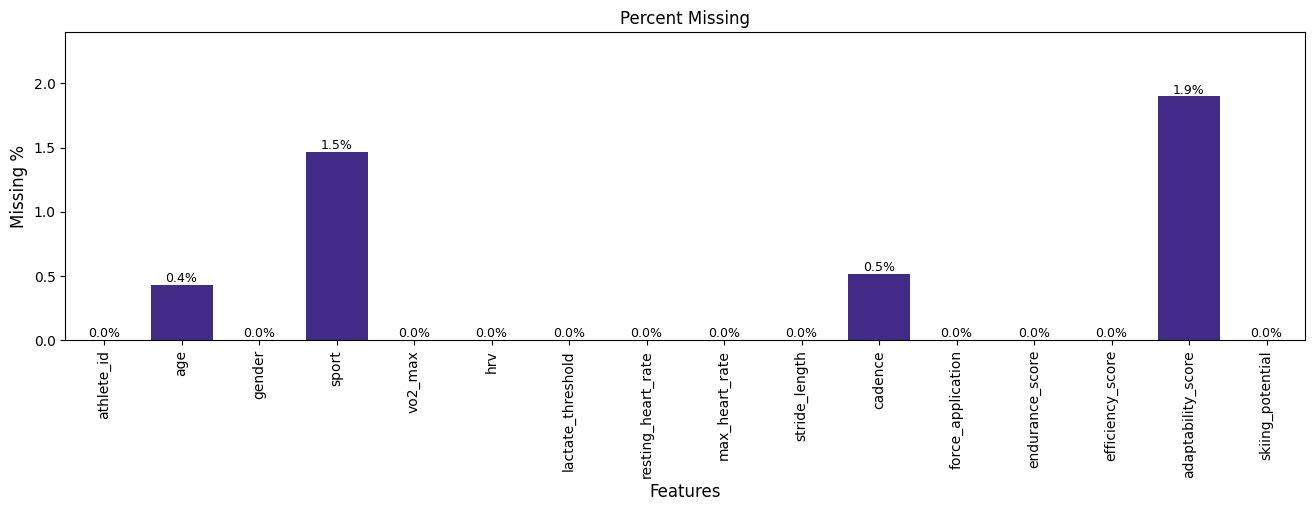

In [17]:
# Визуализируем долю пропусков для колонок
nan_train_X = ((df.isna().sum() / df.shape[0]*100)).reset_index()
nan_train_X.columns=['feature', 'nan_percent']

colors = ["#3A1C95" if val != "success_index" else "#59BBF8" for val in nan_train_X['feature']]

plt.figure(figsize=(16,4))
ax = sns.barplot(x=nan_train_X['feature'], y=nan_train_X['nan_percent'], palette=colors)
plt.title('Percent Missing')
plt.ylabel('Missing %', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.xticks(rotation=90)

# Добавляем проценты над каждым столбцом
for i, bar in enumerate(ax.patches):
    value = nan_train_X['nan_percent'].iloc[i]
    if not pd.isna(value):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{value:.1f}%',
            ha='center',
            va='bottom',
            fontsize=9
        )
# Устанавливаем максимальное значение оси Y, чтобы "в потолок не упиралось" максимальный по проценту столбец
max_value = nan_train_X['nan_percent'].max()
delta = 0.5  

ax.set_ylim(0, max_value + delta)

plt.show()

In [18]:
# общий процент данных с пропусками
round(1 - df.dropna().shape[0]/df.shape[0], 2)*100

4.0

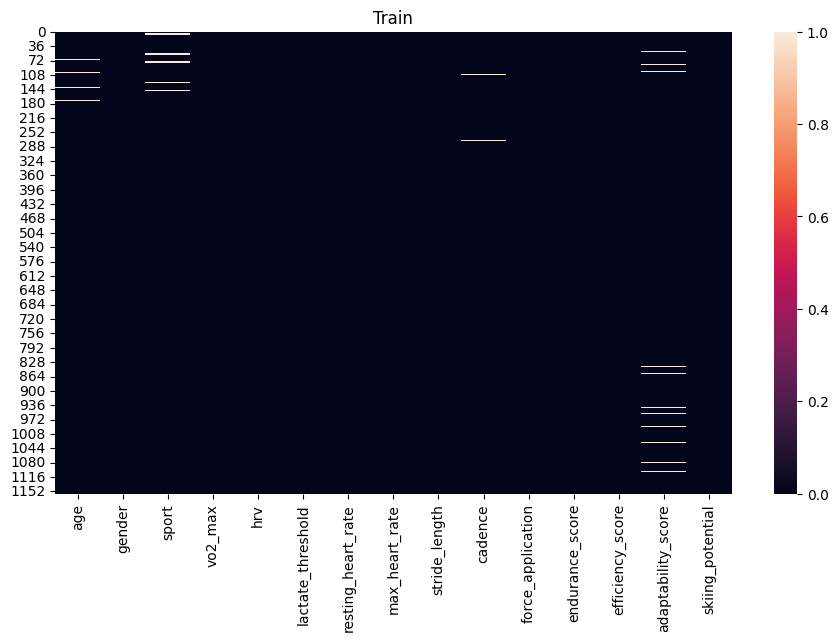

In [19]:
fig = plt.figure(figsize=(24, 6))
ax = fig.add_subplot(1, 2, 1)
ax = sns.heatmap(df[df.columns[1:]].isnull())
ax.title.set_text('Train')
plt.show()

In [21]:
# разделю athlete_id на две части, получив RUN и номер
df[["t_athlete", 'n_athlete']] = df["athlete_id"].str.split('_', expand=True)
df = df.astype({'t_athlete': 'str', 'n_athlete': 'int'})
#Set the Index
df.set_index('athlete_id',inplace=True)

df.head()

,age,gender,sport,vo2_max,hrv,lactate_threshold,resting_heart_rate,max_heart_rate,stride_length,cadence,force_application,endurance_score,efficiency_score,adaptability_score,skiing_potential,t_athlete,n_athlete
athlete_id,,,,,,,,,,,,,,,,,
RUN_1,23.0,Female,Running,62.21,116.50,75.97,45,179,1.08,89.0,466.50,91.94,75.17,91.67,0.54,RUN,1
RUN_2,20.0,Male,Running,50.98,98.90,78.68,41,198,0.80,65.0,528.12,65.22,64.80,80.85,0.13,RUN,2
RUN_3,22.0,Female,Running,68.55,56.96,72.11,49,179,0.92,97.0,304.43,50.73,61.85,93.61,0.93,RUN,3
RUN_4,26.0,Female,Running,57.89,56.20,83.94,56,192,0.89,60.0,520.07,77.56,94.52,70.17,0.15,RUN,4
RUN_5,22.0,Male,NaN,56.31,101.21,80.60,58,176,1.47,66.0,340.50,74.46,52.44,52.87,0.03,RUN,5


In [22]:
# соберем в отдельный список все категориальные признаки
categorical_features = df.select_dtypes(include = ['object']).columns.to_list()

# соберем в отдельный список все числовые признаки
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.to_list()

print("Категориальные признаки:")
print(categorical_features)
print("--------------------------")
print("Числовые признаки:")
print(numeric_features)

Категориальные признаки:
['gender', 'sport', 't_athlete']
--------------------------
Числовые признаки:
['age', 'vo2_max', 'hrv', 'lactate_threshold', 'resting_heart_rate', 'max_heart_rate', 'stride_length', 'cadence', 'force_application', 'endurance_score', 'efficiency_score', 'adaptability_score', 'skiing_potential', 'n_athlete']


In [23]:
# заполняю null в категориальном признаке 'sport' значение 'Running'
df['sport'] = df['sport'].fillna('Running')

In [24]:
# заполняю пропуски в числовых признаках средним значением
for col in ['age', 'cadence', 'adaptability_score']:
    df[col] = df[col].fillna(df[col].mean()).astype(float)

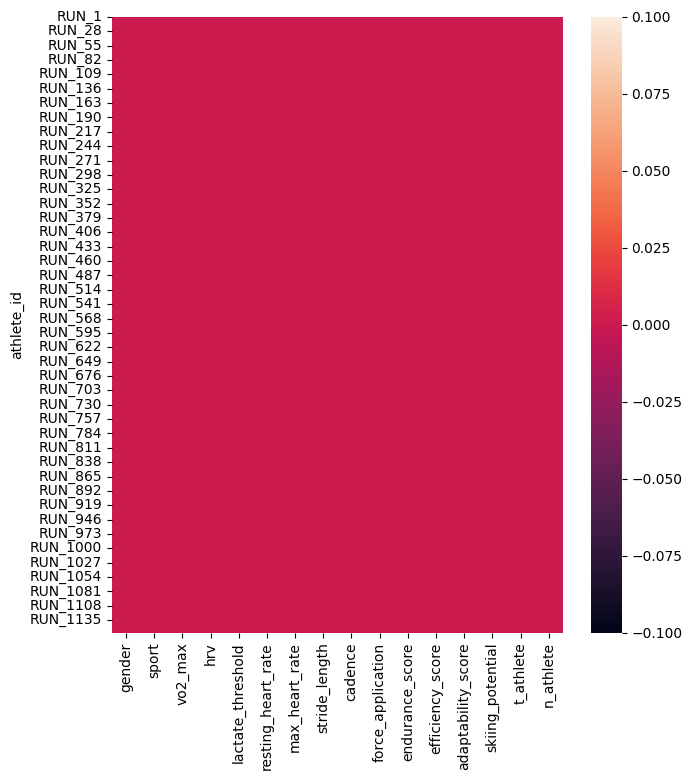

In [25]:
# итоговая проверка. Видим, что пропущенные значения отсутствуют
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(1, 2, 1)
ax = sns.heatmap(df[df.columns[1:]].isnull())

plt.show()

In [26]:
scaler = StandardScaler()
ohe=OneHotEncoder(sparse_output=False)
data_scaled = scaler.fit_transform(df[numeric_features])
data_ohe = ohe.fit_transform(df[categorical_features])

In [27]:
print(data_scaled)
print(data_ohe)

[[-0.63266198 -0.03464864  1.58106013 ...  1.114374    0.13312073
  -1.73055573]
 [-1.2575557  -1.12970471  0.69214601 ...  0.36712583 -1.28430607
  -1.72756427]
 [-0.84095989  0.58357535 -1.42609595 ...  1.2483538   1.48140476
  -1.72457282]
 ...
 [ 1.24201917 -1.44369229 -1.47003659 ... -0.13495311 -1.31887746
   1.72457282]
 [-1.0492578   0.15354888 -1.36094258 ... -1.01134675 -0.86944945
   1.72756427]
 [-1.46585361  0.92584132 -1.59428254 ... -1.61356524  1.27397645
   1.73055573]]
[[1. 0. 1. 1.]
 [0. 1. 1. 1.]
 [1. 0. 1. 1.]
 ...
 [0. 1. 1. 1.]
 [1. 0. 1. 1.]
 [0. 1. 1. 1.]]


In [28]:
# Выбираю только числовые признаки
numeric_df = df.select_dtypes(include=[np.number])

# Вычисляю матрицу корреляции
correlation_matrix = numeric_df.corr()

print("Матрица корреляции:")
print(correlation_matrix)

Матрица корреляции:
                         age   vo2_max       hrv  lactate_threshold  \
age                 1.000000  0.016397  0.017957           0.018024   
vo2_max             0.016397  1.000000 -0.010722           0.004520   
hrv                 0.017957 -0.010722  1.000000           0.040363   
lactate_threshold   0.018024  0.004520  0.040363           1.000000   
resting_heart_rate  0.029465 -0.049014 -0.025536          -0.019692   
max_heart_rate     -0.022441 -0.051719 -0.001713          -0.021075   
stride_length       0.022477 -0.009478 -0.000805          -0.062956   
cadence            -0.010098 -0.016209  0.022536           0.024447   
force_application  -0.042548 -0.027446 -0.039133           0.033903   
endurance_score    -0.039804 -0.005570 -0.000589           0.000341   
efficiency_score   -0.006489 -0.043677 -0.014536          -0.033393   
adaptability_score  0.072308  0.021473 -0.035187           0.011786   
skiing_potential   -0.034004 -0.003044 -0.018366         

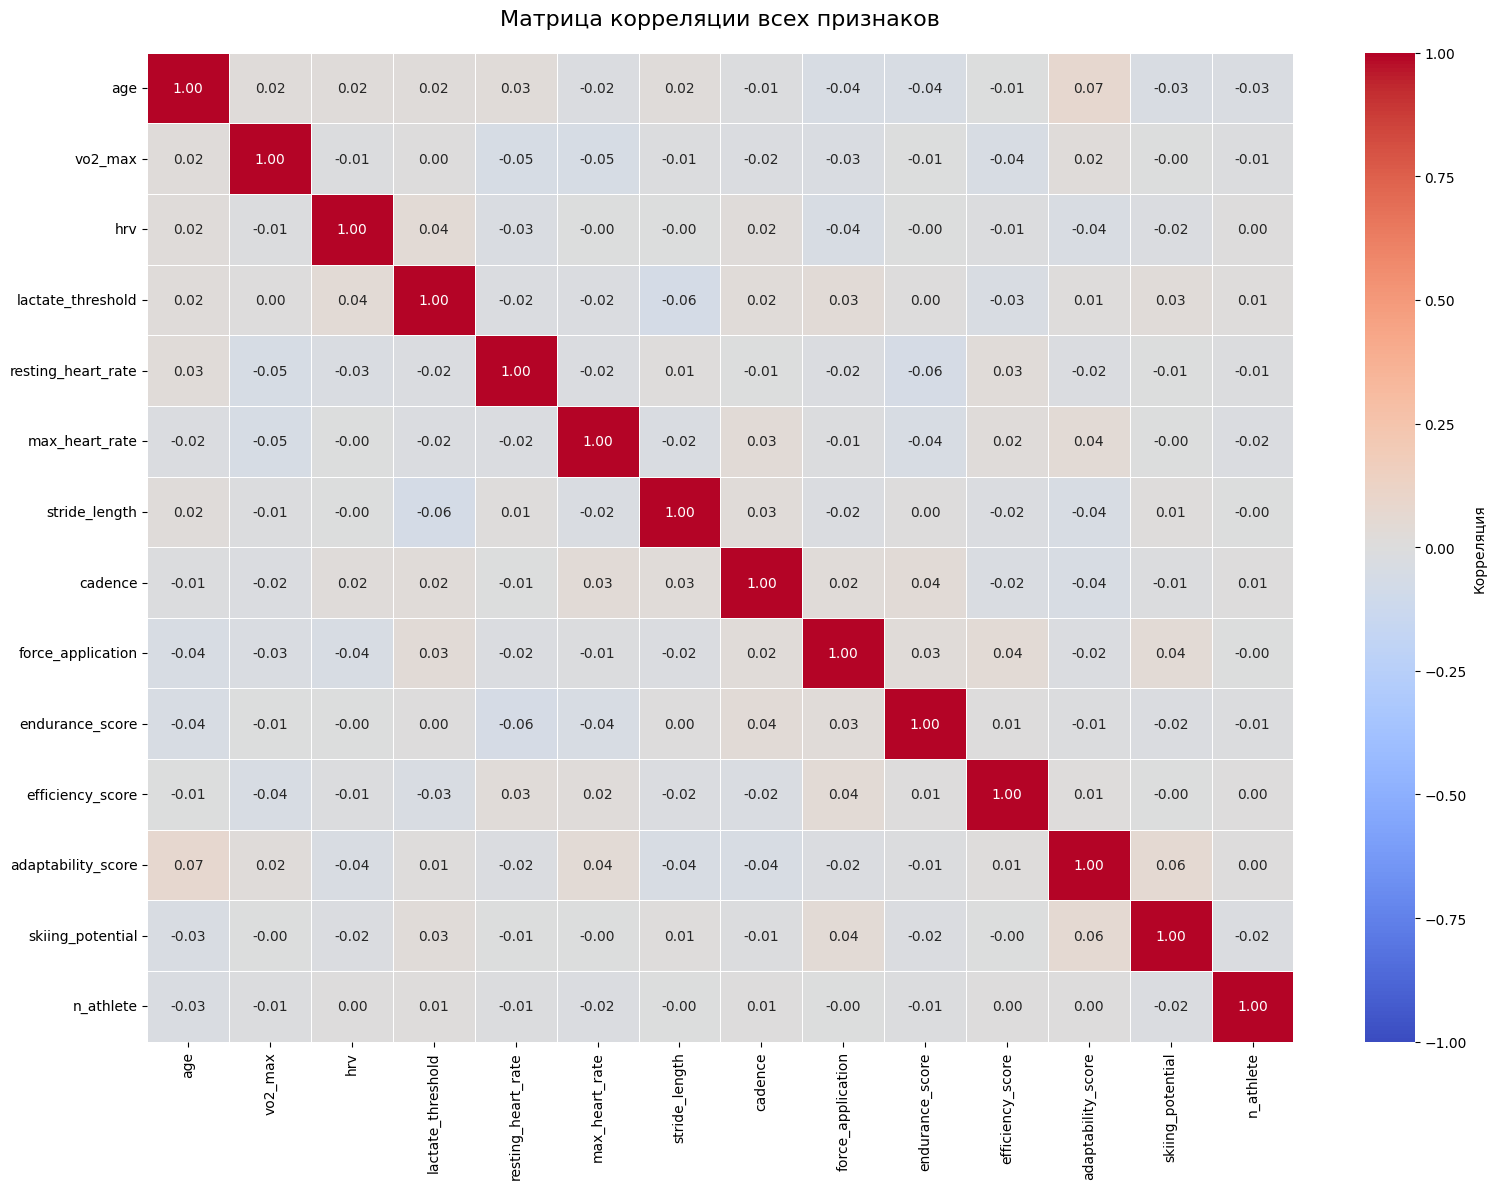

In [29]:
# Создаю большую тепловую карту для всех признаков
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'label': 'Корреляция'})
plt.title('Матрица корреляции всех признаков', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

Важность признаков:
               Feature  Importance
4     efficiency_score    0.920913
10  adaptability_score    0.012291
3    lactate_threshold    0.010666
0              vo2_max    0.009235
9    force_application    0.008562
7        stride_length    0.008290
5      endurance_score    0.007540
1                  hrv    0.007068
6       max_heart_rate    0.005832
8              cadence    0.005240
2   resting_heart_rate    0.004362


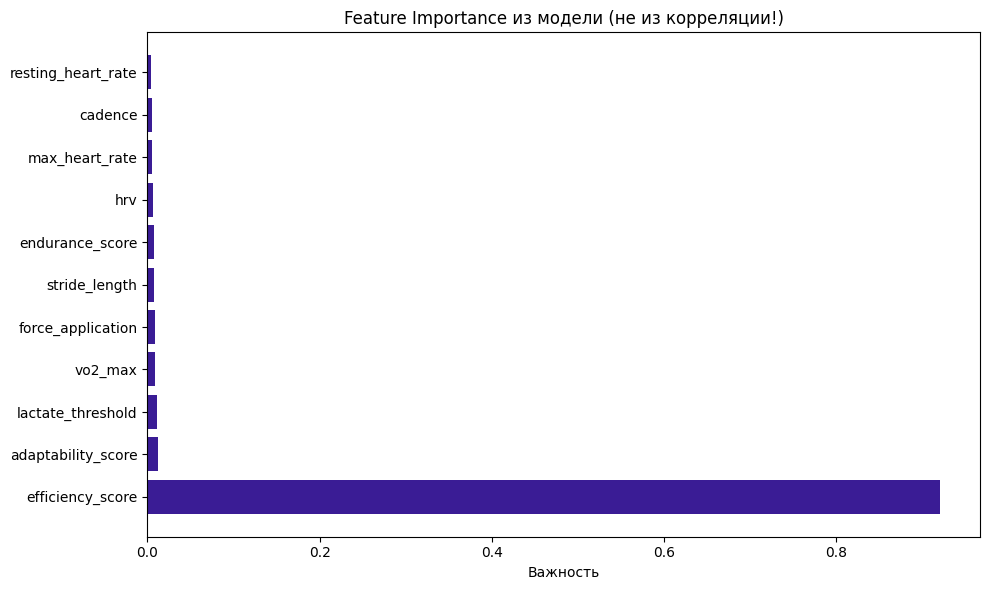

In [30]:
# Подготовливаю целевую переменную
key_features = ['vo2_max', 'hrv', 'resting_heart_rate', 'lactate_threshold', 'efficiency_score', 
                'endurance_score', 'max_heart_rate', 'stride_length', 'cadence', 'force_application',
                'adaptability_score']

df_clean = df.dropna(subset=key_features)
df_clean['target'] = (df_clean['efficiency_score'] > df_clean['efficiency_score'].quantile(0.5)).astype(int)

# Нормализую
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[key_features])

# Обучить модель со ВСЕМИ признаками
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_scaled, df_clean['target'])

# Посмотрите важность
feature_importance = pd.DataFrame({
    'Feature': key_features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Важность признаков:")
print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color="#3A1C95")
plt.xlabel('Важность')
plt.title('Feature Importance из модели (не из корреляции!)')
plt.tight_layout()
plt.show()


In [31]:
key_features = ['vo2_max', 'hrv', 'lactate_threshold', 'efficiency_score', 
                'endurance_score', 'adaptability_score']

#НОРМАЛИЗАЦИЯ
scaler = StandardScaler()
df = pd.DataFrame(
    scaler.fit_transform(df[key_features]),
    columns=key_features
)

#КОНСТРУИРОВАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (на обработанных данных!)
weights = {
    'vo2_max': 0.10,
    'lactate_threshold': 0.15,
    'efficiency_score': 0.40,
    'endurance_score': 0.15,
    'adaptability_score': 0.15,
    'hrv': 0.05
}

df['success_index'] = 0
for i, feature in enumerate(key_features):
    df['success_index'] += df.iloc[:, i] * list(weights.values())[i]

#ЦЕЛЕВАЯ ПЕРЕМЕННАЯ
df['successful_completion'] = (
    df['success_index'] > df['success_index'].median()
).astype(int)

print("Распределение классов целевой переменной:")
print(df['successful_completion'].value_counts())
print(f"\nКорректность: {df['successful_completion'].isna().sum()} пропусков")

Распределение классов целевой переменной:
successful_completion
1    579
0    579
Name: count, dtype: int64

Корректность: 0 пропусков


In [32]:
# Очистка данные
df_clean = df.dropna(subset=key_features + ['successful_completion'])

X = df_clean[key_features]
y = df_clean['successful_completion']

# Разделяю данные ан train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()
y_train = y_train.copy()
y_test = y_test.copy()

# Нормализация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print(f"Тренировочный набор: {X_train.shape}")
print(f"Тестовый набор: {X_test.shape}")
print(f"\nРаспределение в тренировочном наборе:\n{y_train.value_counts()}")

Тренировочный набор: (926, 6)
Тестовый набор: (232, 6)

Распределение в тренировочном наборе:
successful_completion
1    463
0    463
Name: count, dtype: int64


# Стекинг (Stacking) с Optuna

In [33]:
def objective_stacking(trial):
    """
    Функция цели для оптимизации стекинга
    """
    
    # 1. Гиперпараметры для базовых моделей
    rf_n_estimators = trial.suggest_int('rf_n_estimators', 50, 200)
    rf_max_depth = trial.suggest_int('rf_max_depth', 5, 20)
    
    gb_n_estimators = trial.suggest_int('gb_n_estimators', 50, 200)
    gb_learning_rate = trial.suggest_float('gb_learning_rate', 0.01, 0.3)
    
    svc_c = trial.suggest_float('svc_c', 0.1, 100, log=True)
    
    # 2. Гиперпараметры для логистической регрессии (мета-модель)
    lr_c = trial.suggest_float('lr_c', 0.1, 100, log=True)
    
    # 3. Базовые модели
    base_learners = [
        ('rf', RandomForestClassifier(
            n_estimators=rf_n_estimators,
            max_depth=rf_max_depth,
            random_state=42,
            n_jobs=-1
        )),
        ('gb', GradientBoostingClassifier(
            n_estimators=gb_n_estimators,
            learning_rate=gb_learning_rate,
            random_state=42
        )),
        ('svc', SVC(C=svc_c, kernel='rbf', probability=True, random_state=42))
    ]
    
    # 4. Мета-модель (финальный классификатор)
    meta_model = LogisticRegression(C=lr_c, max_iter=1000, random_state=42)
    
    # 5. Создаю стекинг классификатор
    stacking_model = StackingClassifier(
        estimators=base_learners,
        final_estimator=meta_model,
        cv=5  # 5-fold кросс-валидация для генерации метапризнаков
    )
    
    # 6. Кросс-валидация
    scores = cross_val_score(
        stacking_model, X_train_scaled, y_train,
        cv=5, scoring='accuracy'
    )
    
    return scores.mean()

# Запускаю оптимизацию для стекинга
print("Оптимизация СТЕКИНГА...")
study_stacking = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_stacking.optimize(objective_stacking, n_trials=30, show_progress_bar=True)

print(f"\nЛучшие гиперпараметры (Стекинг): {study_stacking.best_params}")
print(f"Лучшая точность: {study_stacking.best_value:.4f}")

[I 2026-06-24 14:09:23,563] A new study created in memory with name: no-name-bfcc2beb-f15d-4170-ac1c-1ad6468b67b4


Оптимизация СТЕКИНГА...


Best trial: 0. Best value: 0.953577:   3%|▎         | 1/30 [00:19<09:13, 19.09s/it]

[I 2026-06-24 14:09:42,656] Trial 0 finished with value: 0.9535774484161582 and parameters: {'rf_n_estimators': 106, 'rf_max_depth': 20, 'gb_n_estimators': 160, 'gb_learning_rate': 0.18361096041714062, 'svc_c': 0.2938027938703535, 'lr_c': 0.2937538457632829}. Best is trial 0 with value: 0.9535774484161582.


Best trial: 1. Best value: 0.957884:   7%|▋         | 2/30 [00:33<07:44, 16.60s/it]

...

[I 2026-06-24 14:17:45,271] Trial 27 finished with value: 0.9632955536181343 and parameters: {'rf_n_estimators': 181, 'rf_max_depth': 19, 'gb_n_estimators': 115, 'gb_learning_rate': 0.1432123272159842, 'svc_c': 0.46489251927836356, 'lr_c': 8.12187939272183}. Best is trial 27 with value: 0.9632955536181343.


Best trial: 28. Best value: 0.965452:  97%|█████████▋| 29/30 [08:41<00:19, 19.38s/it]

[I 2026-06-24 14:18:05,050] Trial 28 finished with value: 0.9654519035164195 and parameters: {'rf_n_estimators': 184, 'rf_max_depth': 19, 'gb_n_estimators': 98, 'gb_learning_rate': 0.14148052865293004, 'svc_c': 0.41694915817538103, 'lr_c': 8.299545915215292}. Best is trial 28 with value: 0.9654519035164195.


Best trial: 29. Best value: 0.966533: 100%|██████████| 30/30 [09:01<00:00, 18.03s/it]

[I 2026-06-24 14:18:24,603] Trial 29 finished with value: 0.9665329845975007 and parameters: {'rf_n_estimators': 180, 'rf_max_depth': 18, 'gb_n_estimators': 98, 'gb_learning_rate': 0.17527258793262468, 'svc_c': 0.41201517120486236, 'lr_c': 20.812479192277646}. Best is trial 29 with value: 0.9665329845975007.

Лучшие гиперпараметры (Стекинг): {'rf_n_estimators': 180, 'rf_max_depth': 18, 'gb_n_estimators': 98, 'gb_learning_rate': 0.17527258793262468, 'svc_c': 0.41201517120486236, 'lr_c': 20.812479192277646}
Лучшая точность: 0.9665


# Ансамбль с Бустингом и Логистической Регрессией

In [34]:
def objective_boosting_ensemble(trial):
    """
    Функция цели для оптимизации ансамбля с бустингом
    """
    
    # Гиперпараметры для GradientBoosting
    gb_n_estimators = trial.suggest_int('gb_n_estimators', 50, 200)
    gb_learning_rate = trial.suggest_float('gb_learning_rate', 0.01, 0.3)
    gb_max_depth = trial.suggest_int('gb_max_depth', 3, 10)
    
    # Гиперпараметры для RandomForest
    rf_n_estimators = trial.suggest_int('rf_n_estimators', 50, 200)
    
    # Базовые модели с бустингом
    base_learners = [
        ('gb', GradientBoostingClassifier(
            n_estimators=gb_n_estimators,
            learning_rate=gb_learning_rate,
            max_depth=gb_max_depth,
            random_state=42
        )),
        ('rf', RandomForestClassifier(
            n_estimators=rf_n_estimators,
            random_state=42,
            n_jobs=-1
        ))
    ]
    
    # VotingClassifier (голосование) или StackingClassifier
    voting_model = VotingClassifier(
        estimators=base_learners,
        voting='soft'  # 'soft' для вероятностных предсказаний
    )
    
    # Кросс-валидация
    scores = cross_val_score(
        voting_model, X_train_scaled, y_train,
        cv=5, scoring='accuracy'
    ) 
    return scores.mean()

# Запускаю оптимизацию для бустинга
print("Оптимизация БУСТИНГА...")
study_boosting = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_boosting.optimize(objective_boosting_ensemble, n_trials=30, show_progress_bar=True)

print(f"\nЛучшие гиперпараметры (Бустинг): {study_boosting.best_params}")
print(f"Лучшая точность: {study_boosting.best_value:.4f}")

[I 2026-06-24 14:19:26,599] A new study created in memory with name: no-name-eb2e8038-259f-44c1-8766-1a7f601d61c8


Оптимизация БУСТИНГА...


Best trial: 0. Best value: 0.877983:   3%|▎         | 1/30 [00:02<01:11,  2.46s/it]

[I 2026-06-24 14:19:29,063] Trial 0 finished with value: 0.8779831444347573 and parameters: {'gb_n_estimators': 106, 'gb_learning_rate': 0.28570714885887566, 'gb_max_depth': 8, 'rf_n_estimators': 140}. Best is trial 0 with value: 0.8779831444347573.


Best trial: 1. Best value: 0.917931:   7%|▋         | 2/30 [00:04<01:00,  2.16s/it]

...

[I 2026-06-24 14:21:35,423] Trial 27 finished with value: 0.9330659691950014 and parameters: {'gb_n_estimators': 140, 'gb_learning_rate': 0.22074319216630545, 'gb_max_depth': 3, 'rf_n_estimators': 189}. Best is trial 27 with value: 0.9330659691950014.


Best trial: 27. Best value: 0.933066:  97%|█████████▋| 29/30 [02:16<00:05,  5.66s/it]

[I 2026-06-24 14:21:43,523] Trial 28 finished with value: 0.8725661145015984 and parameters: {'gb_n_estimators': 185, 'gb_learning_rate': 0.09283456014388253, 'gb_max_depth': 9, 'rf_n_estimators': 177}. Best is trial 27 with value: 0.9330659691950014.


Best trial: 27. Best value: 0.933066: 100%|██████████| 30/30 [02:21<00:00,  4.71s/it]

[I 2026-06-24 14:21:47,806] Trial 29 finished with value: 0.9201046207497822 and parameters: {'gb_n_estimators': 105, 'gb_learning_rate': 0.2896737931949068, 'gb_max_depth': 5, 'rf_n_estimators': 140}. Best is trial 27 with value: 0.9330659691950014.

Лучшие гиперпараметры (Бустинг): {'gb_n_estimators': 140, 'gb_learning_rate': 0.22074319216630545, 'gb_max_depth': 3, 'rf_n_estimators': 189}
Лучшая точность: 0.9331


In [35]:
# ============ Функция цели для Optuna ============
def objective(trial):
    # Гиперпараметры
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    
    # Нормализацяи
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Создаю модель
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )
    
    # Кросс-валидация
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    return scores.mean()

# ============ Создание и запуск исследования ============
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

# ============ Результаты ============
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ OPTUNA")
print("="*50)
print(f"\nЛучшие гиперпараметры:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")
print(f"\nЛучшая точность (CV): {study.best_value:.4f}")


[I 2026-06-24 14:22:12,336] A new study created in memory with name: no-name-d048de98-650d-41c1-93cf-d1d78f306afa
Best trial: 0. Best value: 0.925481:   2%|▏         | 1/50 [00:01<00:57,  1.17s/it]

[I 2026-06-24 14:22:13,506] Trial 0 finished with value: 0.9254809648358036 and parameters: {'n_estimators': 144, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.9254809648358036.


Best trial: 0. Best value: 0.925481:   4%|▍         | 2/50 [00:01<00:45,  1.06it/s]

[I 2026-06-24 14:22:14,289] Trial 1 finished with value: 0.9211740773031096 and parameters: {'n_estimators': 89, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9254809648358036.


Best trial: 0. Best value: 0.925481:   6%|▌         | 3/50 [00:03<00:53,  1.13s/it]

...

[I 2026-06-24 14:23:41,868] Trial 47 finished with value: 0.9330485324033709 and parameters: {'n_estimators': 94, 'max_depth': 30, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 47 with value: 0.9330485324033709.


Best trial: 47. Best value: 0.933049:  98%|█████████▊| 49/50 [01:30<00:01,  1.04s/it]

[I 2026-06-24 14:23:43,033] Trial 48 finished with value: 0.9298169136878813 and parameters: {'n_estimators': 99, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 2}. Best is trial 47 with value: 0.9330485324033709.


Best trial: 47. Best value: 0.933049: 100%|██████████| 50/50 [01:31<00:00,  1.84s/it]

[I 2026-06-24 14:23:44,150] Trial 49 finished with value: 0.9265678581807615 and parameters: {'n_estimators': 94, 'max_depth': 29, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 47 with value: 0.9330485324033709.

РЕЗУЛЬТАТЫ OPTUNA

Лучшие гиперпараметры:
  n_estimators: 94
  max_depth: 30
  min_samples_split: 4
  min_samples_leaf: 2

Лучшая точность (CV): 0.9330


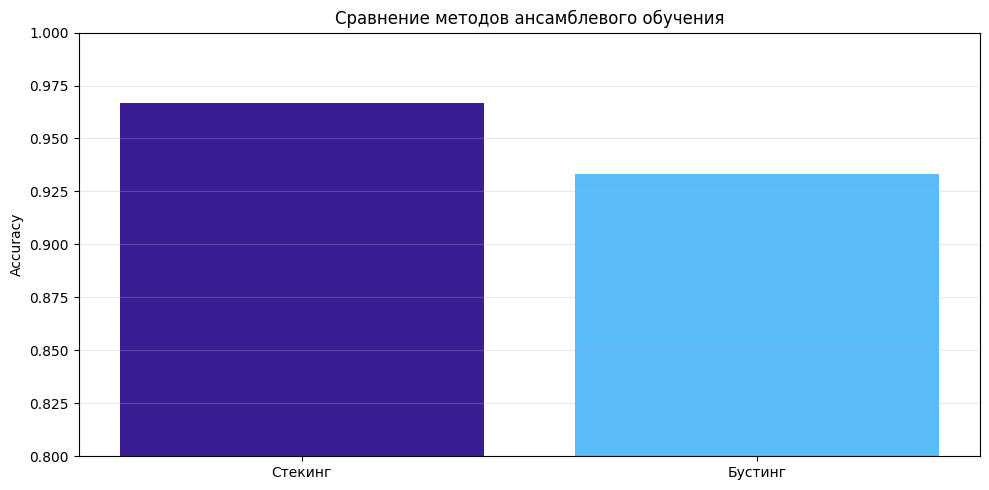


ИТОГОВОЕ СРАВНЕНИЕ
Стекинг         : 0.9665
Бустинг         : 0.9331


In [47]:
# Получаю лучшие значения из каждого исследования Optuna
results = {
    'Стекинг': study_stacking.best_value,      # accuracy из стекинга
    'Бустинг': study_boosting.best_value       # accuracy из бустинга
}

# Визуализация
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values(), color=["#3A1C95", "#59BBF8"])
plt.ylabel('Accuracy')
plt.title('Сравнение методов ансамблевого обучения')
plt.ylim([0.8, 1.0])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод результатов
print("\n" + "="*60)
print("ИТОГОВОЕ СРАВНЕНИЕ")
print("="*60)

sorted_results = sorted(results.items(), key=operator.itemgetter(1), reverse=True)
for method, accuracy in sorted_results:
    print(f"{method:15} : {accuracy:.4f}")

# Лучшие параметры Стекинга

In [48]:
best_params = study_stacking.best_params

In [49]:
# Модель с лучшими параметрами
base_learners = [
    ('rf', RandomForestClassifier(
        n_estimators=best_params['rf_n_estimators'],
        max_depth=best_params['rf_max_depth'],
        random_state=42,
        n_jobs=-1
    )),
    ('gb', GradientBoostingClassifier(
        n_estimators=best_params['gb_n_estimators'],
        learning_rate=best_params['gb_learning_rate'],
        random_state=42
    )),
    ('svc', SVC(
        C=best_params['svc_c'],
        kernel='rbf',
        probability=True,
        random_state=42
    ))
]

meta_model = LogisticRegression(
    C=best_params['lr_c'],
    max_iter=1000,
    random_state=42
)

In [50]:
# Создаю и обучаем стекинг
best_stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_model,
    cv=5
)

# Обучаю на тренировочных данных
best_stacking.fit(X_train, y_train)
print(f"Стекинг обучен. Accuracy на трейне: {best_stacking.score(X_train, y_train):.4f}")

Стекинг обучен. Accuracy на трейне: 0.9849


# «Фенотипы» бегунов

In [51]:
# Только физиологические признаки (без целевых переменных)
physio_features = ['vo2_max', 'hrv', 'lactate_threshold', 
                   'efficiency_score', 'endurance_score', 'adaptability_score']

# Нормализация
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df[physio_features])

In [55]:
# Метод локтя для определения k
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)


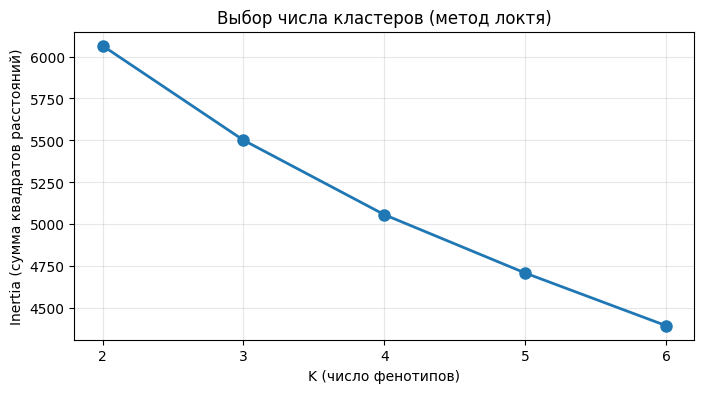

Характеристика фенотипов бегунов:
                  vo2_max   hrv  lactate_threshold  efficiency_score  \
runner_phenotype                                                       
0                    0.17  0.80               0.28              0.50   
1                   -0.10 -0.58              -0.32              0.91   
2                    0.08 -0.76               0.05             -0.85   
3                   -0.12  0.62               0.05             -0.67   

                  endurance_score  adaptability_score  
runner_phenotype                                       
0                            0.08                0.82  
1                           -0.08               -0.45  
2                           -0.13                0.66  
3                            0.14               -0.88  


In [56]:
# Визуализация
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', linewidth=2, markersize=8)
plt.title('Выбор числа кластеров (метод локтя)')
plt.xlabel('K (число фенотипов)')
plt.ylabel('Inertia (сумма квадратов расстояний)')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

# Оптимальное k =4
optimal_k = 4  # или 3, смотрите по графику
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['runner_phenotype'] = kmeans.fit_predict(X_cluster)

# Интерпретация кластеров
print("Характеристика фенотипов бегунов:")
print(df.groupby('runner_phenotype')[physio_features].mean().round(2))

In [57]:
# Анализ целевой переменной по кластерам
analysis = df.groupby('runner_phenotype').agg({
    'successful_completion': ['mean', 'count'],  # или 'success_index'
    'vo2_max': 'mean',
    'hrv': 'mean', 
    'efficiency_score': 'mean',
    'endurance_score': 'mean',
    'adaptability_score': 'mean'
}).round(2)

print("Анализ успешности по фенотипам:")
print(analysis)

Анализ успешности по фенотипам:
                 successful_completion       vo2_max   hrv efficiency_score  \
                                  mean count    mean  mean             mean   
runner_phenotype                                                              
0                                 0.79   268    0.17  0.80             0.50   
1                                 0.37   322   -0.10 -0.58             0.91   
2                                 0.38   276    0.08 -0.76            -0.85   
3                                 0.48   292   -0.12  0.62            -0.67   

                 endurance_score adaptability_score  
                            mean               mean  
runner_phenotype                                     
0                           0.08               0.82  
1                          -0.08              -0.45  
2                          -0.13               0.66  
3                           0.14              -0.88  


# Связь с рекомендательной системой

In [58]:
class PhenotypeRecommender:
    def __init__(self, df_with_phenotypes):
        self.profile_stats = df_with_phenotypes.groupby('runner_phenotype').agg({
            'successful_completion': 'mean',
            'vo2_max': 'mean',
            'hrv': 'mean',
            'efficiency_score': 'mean'
        }).to_dict()
        
        self.phenotype_names = {
            0: "Адаптивный элит (высокое восстановление)",
            1: "Техничный любитель (экономичный бег)",
            2: "Перегруженный боец (требуется восстановление)",
            3: "Стабильный марафонец (высокая базовая выносливость)"
        }
        
        self.recommendations = {
            0: {
                'training_type': 'Интервальные тренировки высокой интенсивности',
                'focus': 'Развитие VO2max, скоростная выносливость',
                'volume': 'Средний (60-70 км/нед)',
                'warning': None,
                'success_rate': 'Высокий (85-95%)'
            },
            1: {
                'training_type': 'Силовая подготовка + техника бега',
                'focus': 'Увеличение мощности, работа с lactate threshold',
                'volume': 'Низкий-средний (40-50 км/нед)',
                'warning': 'Избегать высоких объёмов — риск травм из-за низкого восстановления',
                'success_rate': 'Средний (70-80%)'
            },
            2: {
                'training_type': 'Восстановительный бег + компенсационные нагрузки',
                'focus': 'Снижение stress score, улучшение HRV',
                'volume': 'Снижить на 30-40%',
                'warning': 'ВНИМАНИЕ: признаки перетренированности! Обязателен пассивный отдых',
                'success_rate': 'Низкий (50-60%) — не рекомендовать гонки'
            },
            3: {
                'training_type': 'Длительные медленные пробежки + темповые',
                'focus': 'Сохранение базы, постепенное увеличение скорости',
                'volume': 'Высокий (80-100 км/нед)',
                'warning': 'Прогресс медленный — терпение',
                'success_rate': 'Средний-высокий (75-85%) на длинных дистанциях'
            }
        }
    
    def recommend_for_athlete(self, phenotype_id):
        """Возвращает персональную рекомендацию"""
        return {
            'profile': self.phenotype_names[phenotype_id],
            'recommendation': self.recommendations[phenotype_id]
        }

In [59]:
# Использование
recommender = PhenotypeRecommender(df)

# Пример для атлета из кластера 2 (перегруженный)
rec = recommender.recommend_for_athlete(2)
print(f"Фенотип: {rec['profile']}")
print(f"Рекомендация: {rec['recommendation']['training_type']}")
print(f"Предупреждение: {rec['recommendation']['warning']}")

Фенотип: Перегруженный боец (требуется восстановление)
Рекомендация: Восстановительный бег + компенсационные нагрузки
Предупреждение: ВНИМАНИЕ: признаки перетренированности! Обязателен пассивный отдых


# Класс-интегратор «Умный тренер»

In [61]:
from sklearn.base import BaseEstimator, ClassifierMixin

class SmartRunningCoach(BaseEstimator, ClassifierMixin):
    """
    Интегрированная ML-система: 
    Предсказание + Фенотипирование + Персональные рекомендации
    """
    
    def __init__(self, stacking_model, phenotype_clusterer, feature_scaler):
        self.stacking = stacking_model
        self.clusterer = phenotype_clusterer
        self.scaler = feature_scaler
        
        # Маппинг фенотипов
        self.phenotypes = {
            0: {
                'name': 'Адаптивный элит',
                'traits': 'Высокое восстановление (HRV), быстрая адаптация',
                'training_focus': 'Интервалы VO2max, скоростная выносливость',
                'volume': '60-70 км/нед',
                'risk': 'Низкий',
                'tactical_advice': 'Можно агрессивно наращивать объем перед стартом'
            },
            1: {
                'name': 'Техничный любитель', 
                'traits': 'Высокая экономичность при скромных физ. данных',
                'training_focus': 'Силовая работа, техника, lactate threshold',
                'volume': '40-50 км/нед (осторожно!)',
                'risk': 'Средний (риск травм при перегрузке)',
                'tactical_advice': 'Фокус на качестве, а не количестве километров'
            },
            2: {
                'name': 'Перегруженный боец',
                'traits': 'Низкий HRV, высокая адаптивность, но стресс',
                'training_focus': 'Восстановление, сон, компенсация',
                'volume': 'Снизить на 30-40%',
                'risk': 'Высокий (перетренированность!)',
                'tactical_advice': 'Отменить гонки ближайшие 2-3 недели, массаж, сон >8ч'
            },
            3: {
                'name': 'Стабильный марафонец',
                'traits': 'Высокая базовая выносливость, консервативный прогресс',
                'training_focus': 'Длительные медленные, темповые',
                'volume': '80-100 км/нед',
                'risk': 'Низкий',
                'tactical_advice': 'Работать над скоростью медленно'
            }
        }
    
    def predict_proba(self, X):
        """Вероятность успеха"""
        return self.stacking.predict_proba(X)
    
    def predict(self, X):
        """Бинарное предсказание"""
        return self.stacking.predict(X)
    
    def get_phenotype(self, X_physio):
        """Определение фенотипа по физиологическим данным"""
        X_scaled = self.scaler.transform(X_physio)
        cluster_id = self.clusterer.predict(X_scaled)[0]
        return cluster_id, self.phenotypes[cluster_id]
    
    def recommend(self, X_full, X_physio=None):
        """
        Полная рекомендация:
        - Вероятность успеха
        - Фенотип
        - Персональный план
        - Обоснование (почему именно так)
        """
        if X_physio is None:
            # Если подаем только полный X, выделим физио-признаки
            # Предполагается, что порядок признаков как в physio_features
            X_physio = X_full[:, :6]  # первые 6 - физиологические
            
        # 1. ML-прогноз
        prob_success = self.predict_proba(X_full)[:, 1][0]
        binary_pred = self.predict(X_full)[0]
        
        # 2. Фенотип
        pheno_id, pheno_info = self.get_phenotype(X_physio)
        
        # 3. Корректировка рекомендации на основе ML + фенотипа
        # (гибридная логика: даже если фенотип «элит», но ML дает 30% - предупреждаем)
        if prob_success > 0.85:
            readiness = "Высокая готовность к старту"
            race_recommendation = "Можно пробовать личный рекорд"
        elif prob_success > 0.6:
            readiness = "Средняя готовность"
            race_recommendation = "Участвовать, но без агрессивной цели"
        else:
            readiness = "Низкая готовность / риск провала"
            race_recommendation = "Отложить старт или снизить дистанцию"
            # Если фенотип 2 (перегружен) + низкая вероятность - усилить предупреждение
            if pheno_id == 2:
                race_recommendation += " КРИТИЧНО: признаки перетренированности!"
        
        # 4. Комплексная рекомендация
        result = {
            'ml_prediction': {
                'success_probability': round(float(prob_success), 3),
                'binary_prediction': int(binary_pred),
                'confidence': 'Высокая' if abs(prob_success - 0.5) > 0.3 else 'Средняя'
            },
            'phenotype': {
                'id': pheno_id,
                'name': pheno_info['name'],
                'characteristics': pheno_info['traits']
            },
            'training_plan': {
                'focus': pheno_info['training_focus'],
                'weekly_volume': pheno_info['volume'],
                'tactical_notes': pheno_info['tactical_advice']
            },
            'race_readiness': {
                'status': readiness,
                'recommendation': race_recommendation,
                'injury_risk': pheno_info['risk']
            },
            'integrated_advice': self._generate_integrated_advice(pheno_id, prob_success)
        }
        
        return result
    
    def _generate_integrated_advice(self, pheno_id, prob):
        """Генерация объяснения на русском языке"""
        explanations = []
        
        # Объяснение по фенотипу
        if pheno_id == 0:
            explanations.append("Ваш профиль — 'Адаптивный элит'. Вы быстро восстанавливаетесь, ")
            if prob > 0.8:
                explanations.append("и текущая форма подтверждает высокий потенциал. Это идеальное время для пика.")
            else:
                explanations.append("но сейчас наблюдается спад. Скорее всего, недостаточно восстановления между блоками.")
                
        elif pheno_id == 2:
            explanations.append("Профиль 'Перегруженный боец': система фиксирует стресс и низкое HRV. ")
            explanations.append("Несмотря на мотивацию, риск травмы или заболевания критически высок.")
            
        elif pheno_id == 3:
            explanations.append("Вы 'Стабильный марафонец' с сильной базой. ")
            if prob < 0.7:
                explanations.append("Однако текущие показатели ниже вашего потенциала — возможно, усталость от объемов.")
        
        # Объяснение по вероятности
        if prob < 0.5:
            explanations.append(f" Вероятность успеха {prob:.0%} требует корректировки плана.")
        
        return " ".join(explanations)
    
    def visualize_athlete_card(self, recommendation, athlete_id=""):
        """Визуальная карточка атлета (для презентации/отчета)"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f'Анализ атлета {athlete_id}: {recommendation["phenotype"]["name"]}', 
                    fontsize=16, fontweight='bold')
        
        # 1. Вероятность успеха
        ax1 = axes[0, 0]
        prob = recommendation['ml_prediction']['success_probability']
        colors = ['#ff4444' if prob < 0.5 else '#ffbb33' if prob < 0.8 else '#00C851']
        ax1.barh([0], [prob], color=colors, height=0.3)
        ax1.set_xlim(0, 1)
        ax1.set_yticks([])
        ax1.set_xlabel('Вероятность успеха')
        ax1.set_title(f'{prob:.1%}')
        ax1.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
        ax1.axvline(x=0.8, color='green', linestyle='--', alpha=0.5)
        
        # 2. Характеристики фенотипа
        ax2 = axes[0, 1]
        ax2.text(0.1, 0.8, recommendation['phenotype']['characteristics'], 
                fontsize=11, wrap=True, transform=ax2.transAxes)
        ax2.text(0.1, 0.4, f"Риск травмы: {recommendation['race_readiness']['injury_risk']}", 
                fontsize=11, transform=ax2.transAxes, color='red' if recommendation['race_readiness']['injury_risk']=='Высокий' else 'black')
        ax2.set_xlim(0, 1)
        ax2.set_ylim(0, 1)
        ax2.axis('off')
        ax2.set_title('Физиологический профиль')
        
        # 3. Тренировочный фокус
        ax3 = axes[1, 0]
        plan = recommendation['training_plan']
        text = f"Фокус: {plan['focus']}\n\nОбъем: {plan['weekly_volume']}\n\nПримечание: {plan['tactical_notes']}"
        ax3.text(0.1, 0.5, text, fontsize=10, va='center', transform=ax3.transAxes)
        ax3.axis('off')
        ax3.set_title('План тренировок')
        
        # 4. Рекомендация по старту
        ax4 = axes[1, 1]
        status = recommendation['race_readiness']['status']
        color = {'Высокая готовность к старту': 'green', 
                'Средняя готовность': 'orange',
                'Низкая готовность / риск провала': 'red'}[status]
        
        ax4.text(0.5, 0.7, status, fontsize=14, ha='center', color=color, 
                fontweight='bold', transform=ax4.transAxes)
        ax4.text(0.5, 0.4, recommendation['race_readiness']['recommendation'], 
                fontsize=11, ha='center', wrap=True, transform=ax4.transAxes)
        ax4.axis('off')
        
        plt.tight_layout()
        plt.show()

ДЕМОНСТРАЦИЯ РАБОТЫ ИНТЕГРИРОВАННОЙ СИСТЕМЫ


c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\


Анализ атлета #1:
Реальный результат: Провал
ML-прогноз: 1.1% вероятность успеха
Фенотип: Адаптивный элит

Обоснование:
Ваш профиль — 'Адаптивный элит'. Вы быстро восстанавливаетесь,  но сейчас наблюдается спад. Скорее всего, недостаточно восстановления между блоками.  Вероятность успеха 1% требует корректировки плана.

Тренировочный план:
- Фокус: Интервалы VO2max, скоростная выносливость
- Объем: 60-70 км/нед

Рекомендация по старту: Отложить старт или снизить дистанцию


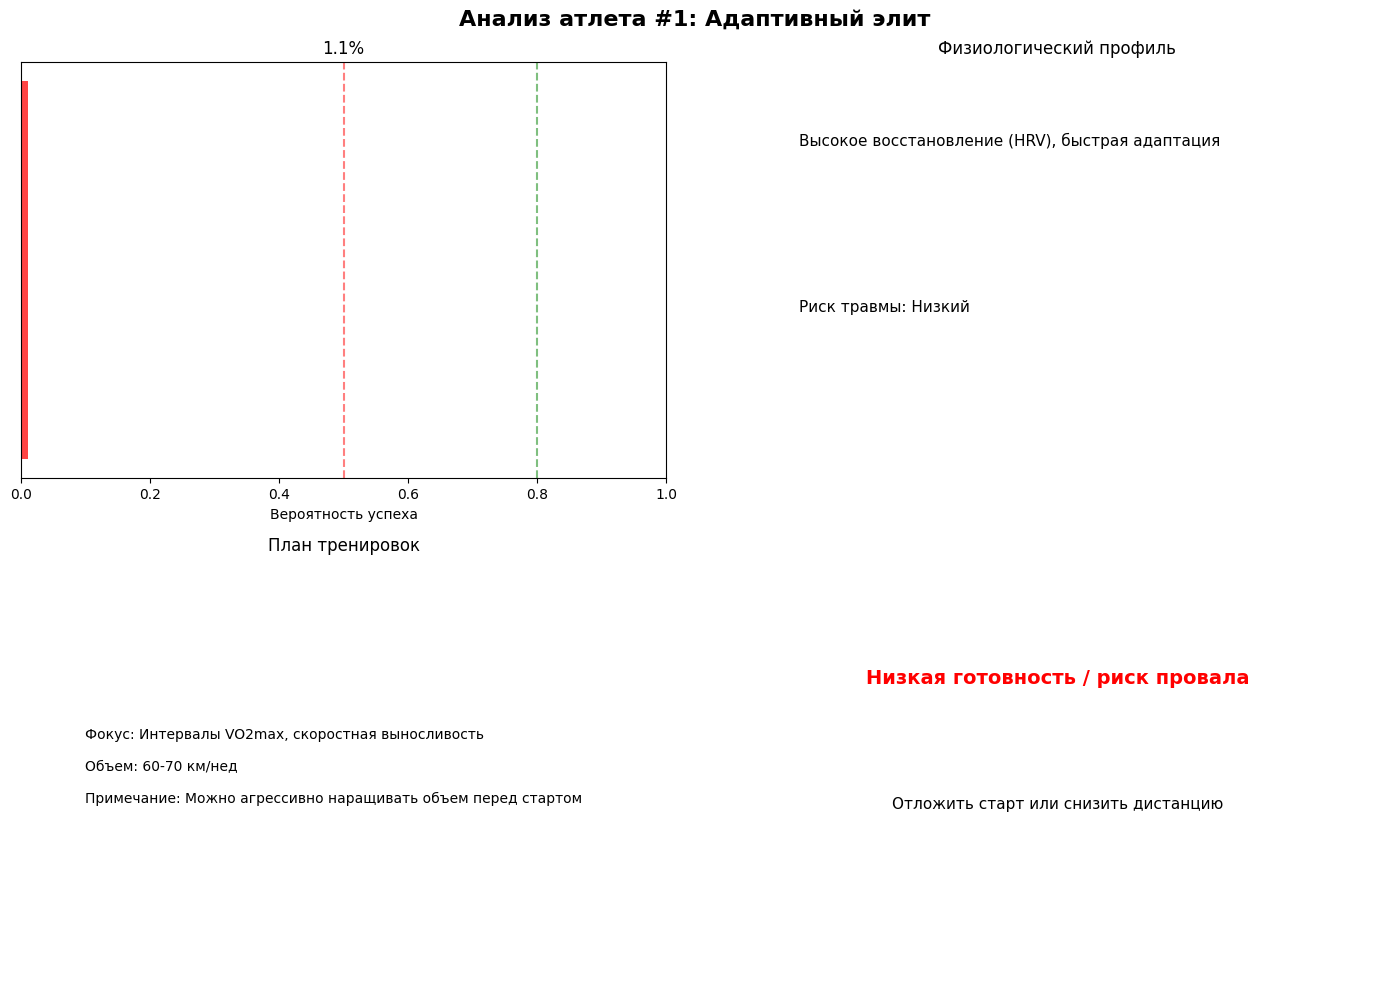

c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\

Калибровка системы:
- Средняя прогнозируемая вероятность для реальных успехов: 0.95
- Средняя прогнозируемая вероятность для реальных провалов: 0.04

Частота провалов по фенотипам:
- Перегруженный боец (2): 72.2%
- Адаптивный элит (0): 25.4%


c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39

In [62]:
# Инициализация системы
coach = SmartRunningCoach(
    stacking_model=best_stacking,   # мой стекинг с лучшими параметрами из Optuna
    phenotype_clusterer=kmeans,     # обученный KMeans (4 кластера)
    feature_scaler=scaler_cluster   # StandardScaler для физио-признаков
)

# Пример использования на тестовом атлете
print("="*60)
print("ДЕМОНСТРАЦИЯ РАБОТЫ ИНТЕГРИРОВАННОЙ СИСТЕМЫ")
print("="*60)

# Беру атлета из тестовой выборки
sample_idx = 1
X_sample = X_test.iloc[[sample_idx]]
y_true = y_test.iloc[sample_idx]

# Для кластеризации нужны только физио-признаки
X_physio_sample = X_sample[physio_features].values

# Получаю полную рекомендацию
rec = coach.recommend(X_sample.values, X_physio_sample)

print(f"\nАнализ атлета #{sample_idx}:")
print(f"Реальный результат: {'Успех' if y_true == 1 else 'Провал'}")
print(f"ML-прогноз: {rec['ml_prediction']['success_probability']:.1%} вероятность успеха")
print(f"Фенотип: {rec['phenotype']['name']}")
print(f"\nОбоснование:")
print(rec['integrated_advice'])
print(f"\nТренировочный план:")
print(f"- Фокус: {rec['training_plan']['focus']}")
print(f"- Объем: {rec['training_plan']['weekly_volume']}")
print(f"\nРекомендация по старту: {rec['race_readiness']['recommendation']}")

# Визуализация
coach.visualize_athlete_card(rec, athlete_id=f"#{sample_idx}")

def evaluate_recommendation_system(coach, X_test, y_test, physio_test):
    """
    Проверяю, что рекомендации системы коррелируют с реальностью
    """
    results = []
    
    for i in range(len(X_test)):
        rec = coach.recommend(X_test.iloc[[i]].values, physio_test.iloc[[i]].values)
        
        results.append({
            'predicted_prob': rec['ml_prediction']['success_probability'],
            'phenotype': rec['phenotype']['id'],
            'actual': y_test.iloc[i],
            'high_risk_flag': rec['race_readiness']['injury_risk'] == 'Высокий'
        })
    
    eval_df = pd.DataFrame(results)
    
    print("Калибровка системы:")
    print(f"- Средняя прогнозируемая вероятность для реальных успехов: "
          f"{eval_df[eval_df['actual']==1]['predicted_prob'].mean():.2f}")
    print(f"- Средняя прогнозируемая вероятность для реальных провалов: "
          f"{eval_df[eval_df['actual']==0]['predicted_prob'].mean():.2f}")
    
    # Проверка: перегруженные атлеты (фенотип 2) действительно чаще проваливаются?
    failure_rate_by_pheno = eval_df.groupby('phenotype')['actual'].apply(lambda x: 1-x.mean())
    print(f"\nЧастота провалов по фенотипам:")
    print(f"- Перегруженный боец (2): {failure_rate_by_pheno[2]:.1%}")
    print(f"- Адаптивный элит (0): {failure_rate_by_pheno[0]:.1%}")
    
    return eval_df

# Запуск оценки
evaluation = evaluate_recommendation_system(coach, X_test, y_test, X_test[physio_features])

# Анализ важности признаков

Важность признаков (Permutation Importance):
              feature  importance       std
2   lactate_threshold    0.393966  0.034494
4     endurance_score    0.106466  0.014938
1                 hrv    0.090948  0.011149
3    efficiency_score    0.074569  0.011733
0             vo2_max    0.048276  0.007662
5  adaptability_score    0.029741  0.010282


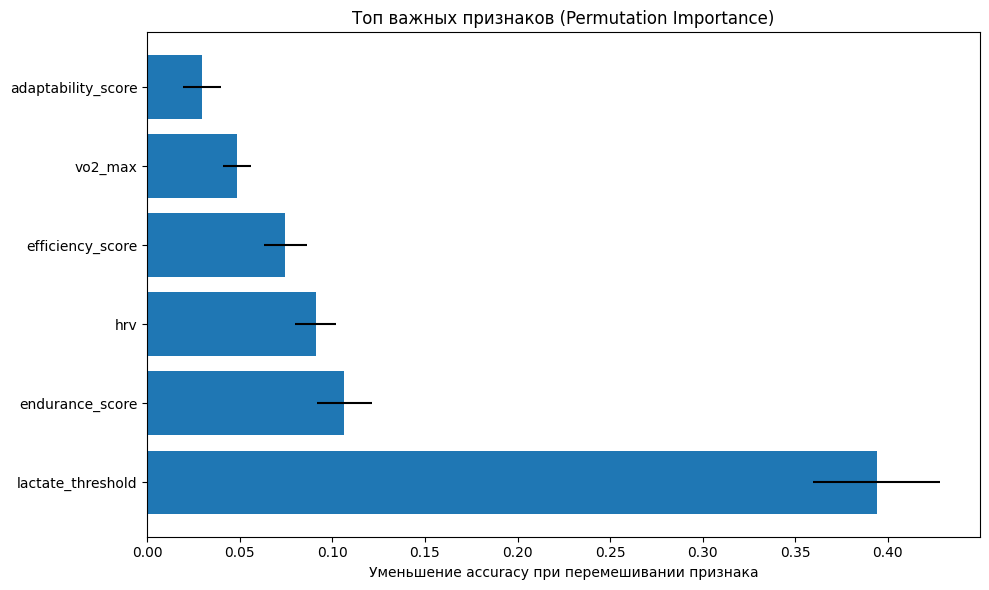


Важность из Random Forest (встроенная):
              feature  importance
2   lactate_threshold    0.584268
4     endurance_score    0.106780
3    efficiency_score    0.096659
1                 hrv    0.094735
0             vo2_max    0.062364
5  adaptability_score    0.055194


In [172]:
# Метод 1: Permutation importance
result = permutation_importance(best_stacking, X_test, y_test, 
                                n_repeats=10, random_state=42, n_jobs=-1)

feat_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=False)

print("Важность признаков (Permutation Importance):")
print(feat_importance.head(10))

# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(feat_importance['feature'][:10], feat_importance['importance'][:10], 
         xerr=feat_importance['std'][:10])
plt.title('Топ важных признаков (Permutation Importance)')
plt.xlabel('Уменьшение accuracy при перемешивании признака')
plt.tight_layout()
plt.show()

# Метод 2: Встроенная важность из RandomForest (если нужно быстро)
rf_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': best_stacking.named_estimators_['rf'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nВажность из Random Forest (встроенная):")
print(rf_importance.head(10))

# Анализ ошибок

Неуверенных предсказаний (40-60%): 6 (2.6%)


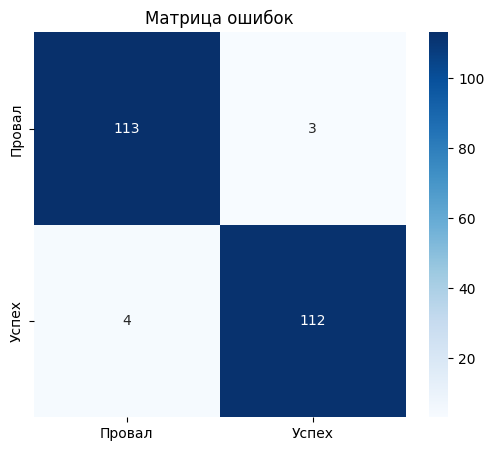

              precision    recall  f1-score   support

      Провал       0.97      0.97      0.97       116
       Успех       0.97      0.97      0.97       116

    accuracy                           0.97       232
   macro avg       0.97      0.97      0.97       232
weighted avg       0.97      0.97      0.97       232



In [173]:
probs = best_stacking.predict_proba(X_test)[:, 1]
preds = best_stacking.predict(X_test)

# Неуверенные случаи
uncertain_mask = (probs > 0.4) & (probs < 0.6)
print(f"Неуверенных предсказаний (40-60%): {uncertain_mask.sum()} "
      f"({uncertain_mask.mean():.1%})")

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Провал', 'Успех'], 
            yticklabels=['Провал', 'Успех'])
plt.title('Матрица ошибок')
plt.show()

# Классификационный отчёт
from sklearn.metrics import classification_report
print(classification_report(y_test, preds, target_names=['Провал', 'Успех']))

# Метрики по фенотипам

In [174]:
# Присоединяю фенотипы к тесту (пересчитываем)
test_physio = X_test[physio_features]
test_phenotypes = kmeans.predict(scaler_cluster.transform(test_physio))

print("Успешность по фенотипам:")
print("-" * 50)

for i in range(4):
    mask = test_phenotypes == i
    if mask.sum() == 0:
        continue
    true_success = y_test[mask].mean()
    pred_probs = probs[mask].mean()
    phenotype_names = ['Адаптивный элит', 'Техничный любитель', 
                      'Перегруженный боец', 'Стабильный марафонец']
    
    print(f"{phenotype_names[i]:<20}: "
          f"Реальная успешность {true_success:.1%} | "
          f"Средняя вер-ть модели {pred_probs:.1%} | "
          f"N={mask.sum()}")

Успешность по фенотипам:
--------------------------------------------------
Адаптивный элит     : Реальная успешность 74.6% | Средняя вер-ть модели 72.2% | N=59
Техничный любитель  : Реальная успешность 42.7% | Средняя вер-ть модели 40.8% | N=75
Перегруженный боец  : Реальная успешность 27.8% | Средняя вер-ть модели 30.5% | N=54
Стабильный марафонец: Реальная успешность 56.8% | Средняя вер-ть модели 58.2% | N=44


# Сравнение с Baseline

In [175]:
# Быстрый baseline
lr = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))

rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

stack_acc = accuracy_score(y_test, best_stacking.predict(X_test))

print("Сравнение моделей:")
print(f"Logistic Regression : {lr_acc:.4f}")
print(f"Random Forest       : {rf_acc:.4f}")
print(f"Stacking (Advanced) : {stack_acc:.4f} (+{(stack_acc-lr_acc)/lr_acc*100:.1f}%)")

Сравнение моделей:
Logistic Regression : 0.9914
Random Forest       : 0.9397
Stacking (Advanced) : 0.9698 (+-2.2%)
